In [1]:
# Physics-Informed CNN ResNet for ERA5 Wave Spectra 
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) 
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) 
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")
print(f"b2: {b2.shape}")

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")
print(f"NaN values in b2: {np.isnan(b2).sum()}")

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26608\1843167754.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [2]:
# Compute baseline reconstruction using directional moments (first harmonic only)
print("Computing baseline spectrum reconstruction...")

def compute_baseline_spectrum(S1D, a1, b1, n_dir=24):
    """Reconstruct 2D spectrum from 1D spectrum and directional moments"""
    # Use exact same directional grid as in preprocessing
    direction_deg = 7.5 + 15 * np.arange(n_dir)  # ERA5 directions: 7.5°, 22.5°, ..., 352.5°
    theta = np.deg2rad(direction_deg)
    ddir = np.deg2rad(15.0)  # 15° spacing
    
    # Initialize output
    S_baseline = np.zeros((S1D.shape[0], S1D.shape[1], n_dir))
    
    for i in range(S1D.shape[0]):
        for j in range(S1D.shape[1]):
            if S1D[i, j] > 1e-15:  # Only process non-zero frequencies
                # Correct first-harmonic directional distribution formula
                D = (1/(2*np.pi)) * (1 + 2*a1[i, j] * np.cos(theta) + 2*b1[i, j] * np.sin(theta))
                
                # Ensure non-negative
                D = np.maximum(D, 0)
                
                # Normalize using discrete integration
                integral = np.sum(D) * ddir
                if integral > 1e-10:
                    D = D / integral
                else:
                    D = np.ones(n_dir) / n_dir  # Uniform if coefficients invalid
                
                # Multiply by 1D spectrum
                S_baseline[i, j, :] = S1D[i, j] * D
    
    return S_baseline



Computing baseline spectrum reconstruction...


In [4]:
# Compute baseline for all samples
S_baseline = compute_baseline_spectrum(S1D, a1, b1)
print(f"Baseline spectrum shape: {S_baseline.shape}")

# Compute residuals (difference between true and baseline spectra)
residuals = S2D - S_baseline
print(f"Residuals shape: {residuals.shape}")
print(f"Residual statistics - Mean: {residuals.mean():.6f}, Std: {residuals.std():.6f}")
print(f"Residual range: [{residuals.min():.6f}, {residuals.max():.6f}]")

# Check energy conservation of baseline
energy_original = np.trapezoid(S2D, dx=2*np.pi/24, axis=2)  # Integrate over directions
energy_baseline = np.trapezoid(S_baseline, dx=2*np.pi/24, axis=2)
energy_ratio = np.mean(energy_baseline) / np.mean(energy_original)
print(f"Energy conservation check - Baseline/Original ratio: {energy_ratio:.6f}")

# Additional checks
print(f"S1D range: [{S1D.min():.6f}, {S1D.max():.6f}]")
print(f"S2D range: [{S2D.min():.6f}, {S2D.max():.6f}]")
print(f"Baseline range: [{S_baseline.min():.6f}, {S_baseline.max():.6f}]")

Baseline spectrum shape: (9504, 30, 24)
Residuals shape: (9504, 30, 24)
Residual statistics - Mean: 0.000000, Std: 0.117018
Residual range: [-4.785140, 14.124423]
Energy conservation check - Baseline/Original ratio: 0.980541
S1D range: [0.000000, 22.504860]
S2D range: [0.000000, 19.814178]
Baseline range: [0.000000, 8.530793]


In [5]:
# Prepare inputs for CNN ResNet model (ALL moments)
print("Preparing inputs for CNN ResNet model...")

# Create model inputs by concatenating ALL features
# Input features: S1D (30) + a1 (30) + b1 (30) + a2 (30) + b2 (30) = 150 features
batch_size, n_freq, n_dir = S2D.shape
n_features = n_freq * 5  # ALL 5 components

# Flatten and concatenate ALL inputs
inputs = np.concatenate([
    S1D.reshape(batch_size, -1),  # Shape: (batch_size, 30)  
    a1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    a2.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b2.reshape(batch_size, -1)    # Shape: (batch_size, 30)
], axis=1)  # Final shape: (batch_size, 150)

# Target is the residual (flattened for MSE)
targets = residuals.reshape(batch_size, -1)  # Shape: (batch_size, 30*24=720)

print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"Input features: {n_features} (S1D + a1 + b1 + a2 + b2)")
print(f"Mode: Residual learning (predict residuals, not full spectrum)")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

# Filter out samples with NaN values
valid_mask = ~(np.isnan(inputs).any(axis=1) | np.isnan(targets).any(axis=1))
print(f"Valid samples: {valid_mask.sum()} / {len(valid_mask)}")

if valid_mask.sum() < len(valid_mask):
    print("Filtering out NaN samples...")
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    S_baseline = S_baseline[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for CNN ResNet model...
Input shape: (9504, 150)
Target shape: (9504, 720)
Input features: 150 (S1D + a1 + b1 + a2 + b2)
Mode: Residual learning (predict residuals, not full spectrum)
NaN in inputs: 0
NaN in targets: 0
Valid samples: 9504 / 9504
Input range: [-0.991445, 22.504860]
Target range: [-4.785140, 14.124423]
Input mean: -0.121308, std: 0.506509
Target mean: 0.000000, std: 0.117018


In [6]:
# Normalize inputs and split data (same as base version)
print("Normalizing inputs and splitting data...")

# Normalize inputs to improve training stability
input_mean = inputs.mean(axis=0, keepdims=True)
input_std = inputs.std(axis=0, keepdims=True) + 1e-8  # Add small epsilon for numerical stability
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/resnet2_res_phy_normalization.npz", input_mean=input_mean, input_std=input_std)

print(f"Input normalization - Mean: {input_mean.mean():.6f}, Std: {input_std.mean():.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")

# For targets, use raw residuals without scaling (same as base version)
targets_norm = targets  # No normalization applied
target_scale = 1.0      # No scaling applied

print(f"Target normalization: None (raw residuals used)")
print(f"Target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Also split baseline spectra and 2D spectra for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]
S_baseline_train = S_baseline[train_idx]
S_baseline_val = S_baseline[val_idx]  
S_baseline_test = S_baseline[test_idx]

# Split individual moment components for physics constraints
S1D_train, S1D_val, S1D_test = S1D[train_idx], S1D[val_idx], S1D[test_idx]
a1_train, a1_val, a1_test = a1[train_idx], a1[val_idx], a1[test_idx]
b1_train, b1_val, b1_test = b1[train_idx], b1[val_idx], b1[test_idx] 
a2_train, a2_val, a2_test = a2[train_idx], a2[val_idx], a2[test_idx]
b2_train, b2_val, b2_test = b2[train_idx], b2[val_idx], b2[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples ({X_train.shape})")
print(f"Val: {X_val.shape[0]} samples ({X_val.shape})")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape})")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

Normalizing inputs and splitting data...
Input normalization - Mean: -0.121308, Std: 0.339513
Normalized input range: [-8.264766, 23.587287]
Target normalization: None (raw residuals used)
Target range: [-4.785140, 14.124423]
Data splits:
Train: 6652 samples ((6652, 150))
Val: 1425 samples ((1425, 150))
Test: 1427 samples ((1427, 150))
Using device: cpu


In [3]:
# Define CNN Residual Block
class CNNResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout_rate=0.1):
        super(CNNResidualBlock, self).__init__()
        
        padding = kernel_size // 2  # Same padding
        
        self.conv1 = nn.Conv2d(channels, channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(channels, channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(channels)
        
        self.dropout = nn.Dropout2d(dropout_rate)
        self.final_relu = nn.ReLU()
    
    def forward(self, x):
        # Save input for skip connection
        identity = x
        
        # First convolution
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout(out)
        
        # Second convolution
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add skip connection
        out += identity
        
        # Final activation
        out = self.final_relu(out)
        
        return out

# Define Physics-Informed CNN ResNet for Residual Learning
class PhysicsInformedCNNResNet(nn.Module):
    def __init__(self, input_size, hidden_channels=64, num_blocks=3, dropout_rate=0.1):
        super(PhysicsInformedCNNResNet, self).__init__()
        
        self.input_size = input_size
        self.hidden_channels = hidden_channels
        self.num_blocks = num_blocks
        
        # Project 1D features to 2D feature map
        # 150 → (64 × 30 × 24)
        self.projection = nn.Linear(input_size, hidden_channels * 30 * 24)
        
        # CNN residual blocks
        self.res_blocks = nn.ModuleList([
            CNNResidualBlock(hidden_channels, kernel_size=3, dropout_rate=dropout_rate) 
            for _ in range(num_blocks)
        ])
        
        # Final convolution to single channel
        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=3, padding=1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # He initialization for ReLU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                # He initialization for linear layers
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Project to 2D feature map
        x = self.projection(x)  # (batch, 64*30*24)
        x = x.reshape(batch_size, self.hidden_channels, 30, 24)  # (batch, 64, 30, 24)
        
        # Apply residual blocks
        for block in self.res_blocks:
            x = block(x)
        
        # Final convolution to single channel
        x = self.final_conv(x)  # (batch, 1, 30, 24)
        x = x.squeeze(1)  # (batch, 30, 24)
        
        # Flatten for MSE loss compatibility
        x = x.reshape(batch_size, -1)  # (batch, 720)
        
        return x

In [8]:
# Create model
input_size = X_train.shape[1]   # 150 features (S1D + a1 + b1 + a2 + b2)
hidden_channels = 64            # CNN hidden channels
num_blocks = 3                  # Number of CNN residual blocks

model = PhysicsInformedCNNResNet(input_size, hidden_channels, num_blocks).to(device)

print(f"Physics-Informed CNN ResNet model created:")
print(f"Input size: {input_size} (S1D + a1 + b1 + a2 + b2)")
print(f"Hidden channels: {hidden_channels}")
print(f"Output size: 720 (30 freq × 24 dir) - residuals")
print(f"CNN residual blocks: {num_blocks}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_batch = X_train_t[:4]  
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("Physics-Informed CNN ResNet architecture defined successfully")

Physics-Informed CNN ResNet model created:
Input size: 150 (S1D + a1 + b1 + a2 + b2)
Hidden channels: 64
Output size: 720 (30 freq × 24 dir) - residuals
CNN residual blocks: 3
Number of parameters: 7,180,993
Test output shape: torch.Size([4, 720])
Test output range: [-46.901447, 32.638351]
Test output has NaN: False
Physics-Informed CNN ResNet architecture defined successfully


In [4]:
# Define loss functions and helper functions
def reconstruct_2d_spectrum(residuals, baseline_flat, target_scale, batch_size, n_freq=30, n_dir=24):
    """Reconstruct 2D spectrum from predicted residuals with energy conservation"""
    # Denormalize residuals
    residuals_scaled = residuals * target_scale
    
    # Reshape to 2D spectrum format
    residuals_2d = residuals_scaled.reshape(batch_size, n_freq, n_dir)
    baseline_2d = baseline_flat.reshape(batch_size, n_freq, n_dir)
    
    # Add residuals to baseline
    reconstructed = baseline_2d + residuals_2d
    
    # Enforce non-negativity
    reconstructed = torch.clamp(reconstructed, min=0.0)
    
    # ✅ ENFORCE ENERGY CONSERVATION
    # Compute integrated energy of reconstructed spectrum
    s1d_reconstructed = torch.trapezoid(reconstructed, dx=2*np.pi/n_dir, dim=2)
    
    # Compute target energy from baseline
    s1d_baseline = torch.trapezoid(baseline_2d, dx=2*np.pi/n_dir, dim=2)
    
    # Correction factor to preserve energy
    correction = s1d_baseline / (s1d_reconstructed + 1e-8)
    
    # Apply correction to force exact energy conservation
    reconstructed = reconstructed * correction.unsqueeze(-1)
    
    return reconstructed

def compute_moments_torch(spectrum_2d, n_dir=24):
    """Compute directional moments from 2D spectrum"""
    # Angular coordinates
    theta = torch.linspace(0, 2*np.pi, n_dir, device=spectrum_2d.device)[None, None, :]
    
    # Integrate over directions for each frequency
    s1d = torch.trapezoid(spectrum_2d, dx=2*np.pi/n_dir, dim=2)
    
    # Compute directional moments
    cos_theta = torch.cos(theta)
    sin_theta = torch.sin(theta)
    
    # Weighted averages
    numerator_a1 = torch.trapezoid(spectrum_2d * cos_theta, dx=2*np.pi/n_dir, dim=2)
    numerator_b1 = torch.trapezoid(spectrum_2d * sin_theta, dx=2*np.pi/n_dir, dim=2)
    
    # Avoid division by zero
    s1d_safe = torch.clamp(s1d, min=1e-15)
    a1 = numerator_a1 / s1d_safe
    b1 = numerator_b1 / s1d_safe
    
    # Clamp moments to valid range [-1, 1]
    a1 = torch.clamp(a1, min=-1, max=1)
    b1 = torch.clamp(b1, min=-1, max=1)
    
    return s1d, a1, b1

def physics_loss(reconstructed, target_2d):
    """Physics-informed loss function"""
    batch_size = reconstructed.shape[0]
    
    # Compute moments for both reconstructed and target
    s1d_recon, a1_recon, b1_recon = compute_moments_torch(reconstructed)
    s1d_target, a1_target, b1_target = compute_moments_torch(target_2d)
    
    # Energy conservation loss
    energy_loss = torch.mean((s1d_recon - s1d_target)**2)
    
    # Moment conservation loss
    moment_loss = torch.mean((a1_recon - a1_target)**2 + (b1_recon - b1_target)**2)
    
    # Spectral shape loss (MSE on full 2D spectrum)
    shape_loss = torch.mean((reconstructed - target_2d)**2)
    
    # Combine losses with weights
    total_loss = 0.7 * shape_loss + 0.2 * energy_loss + 0.1 * moment_loss
    
    return total_loss, shape_loss, energy_loss, moment_loss

In [10]:
# Test loss function
print("Testing loss function...")
with torch.no_grad():
    # Create test tensors
    test_residuals = model(X_train_t[:4])
    test_baseline = torch.FloatTensor(S_baseline_train[:4].reshape(4, -1)).to(device)
    test_target_2d = torch.FloatTensor(S2D_train[:4]).to(device)
    
    # Reconstruct spectrum
    target_scale = 1.0  # Same as MLP version
    test_recon = reconstruct_2d_spectrum(test_residuals, test_baseline, target_scale, 4)
    
    # Compute loss
    total_loss, shape_loss, energy_loss, moment_loss = physics_loss(test_recon, test_target_2d)
    
    print(f"Test losses:")
    print(f"  Total: {total_loss.item():.6f}")
    print(f"  Shape: {shape_loss.item():.6f}")
    print(f"  Energy: {energy_loss.item():.6f}")
    print(f"  Moment: {moment_loss.item():.6f}")
    
    # Check for NaN in loss
    if torch.isnan(total_loss):
        print("WARNING: NaN in loss function!")
    else:
        print("Loss function working correctly")

print("Loss functions defined successfully")

Testing loss function...
Test losses:
  Total: 0.119354
  Shape: 0.006458
  Energy: 0.000077
  Moment: 1.148177
Loss function working correctly
Loss functions defined successfully


In [11]:
# Training setup for Physics-Informed CNN ResNet
print("Setting up physics-informed training...")

# Training hyperparameters (tuned for CNN + physics constraints)
learning_rate = 1e-4    # Same as base ResNet version
batch_size = 32         # Same as base ResNet version
num_epochs = 50         # Same as base ResNet version
weight_decay = 1e-5     # L2 regularization
target_scale = 1.0      # Same as MLP version

# Create data loaders with baseline and target data included (same as MLP version)
train_dataset = TensorDataset(
    X_train_t, y_train_t, 
    torch.FloatTensor(S_baseline_train.reshape(len(S_baseline_train), -1)).to(device), 
    torch.FloatTensor(S2D_train).to(device)
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(
    X_val_t, y_val_t, 
    torch.FloatTensor(S_baseline_val.reshape(len(S_baseline_val), -1)).to(device), 
    torch.FloatTensor(S2D_val).to(device)
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler (same as base ResNet version)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

print(f"Physics-informed training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Target scale: {target_scale}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss: Physics-informed (0.7*shape + 0.2*energy + 0.1*moment)")

# Training history
train_losses = []
val_losses = []
train_mse_losses = []
train_physics_losses = []
best_val_loss = float('inf')

print("Ready to start physics-informed CNN ResNet training")

Setting up physics-informed training...
Physics-informed training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Target scale: 1.0
  Train batches: 208
  Val batches: 45
  Loss: Physics-informed (0.7*shape + 0.2*energy + 0.1*moment)
Ready to start physics-informed CNN ResNet training


In [12]:
# Physics-informed training loop
model_path = "models/resnet_res_phy_en.pth"

print("Starting physics-informed training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    epoch_mse_loss = 0.0
    epoch_physics_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        residuals_pred = model(batch_x)
        
        # Reconstruct 2D spectrum using improved physics-informed function
        target_scale = 1.0  # Same as MLP version
        batch_baseline_flat = batch_baseline.reshape(batch_x.shape[0], -1)
        reconstructed = reconstruct_2d_spectrum(
            residuals_pred, batch_baseline_flat, target_scale, batch_x.shape[0]
        )
      
        # Compute physics-informed loss using unified function
        total_loss, shape_loss, energy_loss, moment_loss = physics_loss(reconstructed, batch_target_2d)
        
        # Check for NaN 
        if torch.isnan(total_loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Residuals range: [{residuals_pred.min().item():.6f}, {residuals_pred.max().item():.6f}]")
            print(f"  Reconstructed range: [{reconstructed.min().item():.6f}, {reconstructed.max().item():.6f}]")
            break
        
        # Backward pass
        total_loss.backward()
        
        # Gradient clipping for stability with physics constraints
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        epoch_train_loss += total_loss.item()
        epoch_mse_loss += shape_loss.item()
        epoch_physics_loss += (energy_loss.item() + moment_loss.item())
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}")
            print(f"    Total: {total_loss.item():.6f}, Shape: {shape_loss.item():.6f}")
            print(f"    Energy: {energy_loss.item():.6f}, Moment: {moment_loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(val_loader):
            # Forward pass
            residuals_pred = model(batch_x)
            
            # Reconstruct 2D spectrum with physics constraints
            target_scale = 1.0
            batch_baseline_flat = batch_baseline.reshape(batch_x.shape[0], -1)
            reconstructed = reconstruct_2d_spectrum(
                residuals_pred, batch_baseline_flat, target_scale, batch_x.shape[0]
            )
            
            # Compute physics-informed loss
            total_loss, _, _, _ = physics_loss(reconstructed, batch_target_2d)
            
            if not torch.isnan(total_loss):
                epoch_val_loss += total_loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    avg_mse_loss = epoch_mse_loss / max(train_batches, 1)
    avg_physics_loss = epoch_physics_loss / max(train_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_mse_losses.append(avg_mse_loss)
    train_physics_losses.append(avg_physics_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Total: {avg_train_loss:.6f} (MSE: {avg_mse_loss:.6f}, Physics: {avg_physics_loss:.6f})")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best physics model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 60)

print("Physics-informed training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting physics-informed training...
  Batch 50/208
    Total: 0.009283, Shape: 0.008115
    Energy: 0.000248, Moment: 0.035529
  Batch 100/208
    Total: 0.004392, Shape: 0.003194
    Energy: 0.000183, Moment: 0.021199
  Batch 150/208
    Total: 0.002377, Shape: 0.001141
    Energy: 0.000086, Moment: 0.015613
  Batch 200/208
    Total: 0.001884, Shape: 0.000613
    Energy: 0.000114, Moment: 0.014322
Epoch 1/50
  Train Total: 0.011602 (MSE: 0.007923, Physics: 0.060160)
  Val Loss: 0.005696
  Learning Rate: 1.00e-04
  ✓ New best physics model saved (val_loss: 0.005696)
------------------------------------------------------------
  Batch 50/208
    Total: 0.002170, Shape: 0.001339
    Energy: 0.000274, Moment: 0.011778
  Batch 100/208
    Total: 0.007127, Shape: 0.008672
    Energy: 0.000378, Moment: 0.009814
  Batch 150/208
    Total: 0.001014, Shape: 0.000475
    Energy: 0.000081, Moment: 0.006649
  Batch 200/208
    Total: 0.008538, Shape: 0.009929
    Energy: 0.004049, Moment: 0.007

In [13]:
# Physics-Informed CNN ResNet Model Evaluation 
print("Evaluating Physics-Informed CNN ResNet model...")
# model_path = "models/resnet_res_phy_new.pth"
# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare test data
S_baseline_test_t = torch.FloatTensor(S_baseline_test.reshape(len(S_baseline_test), -1)).to(device)
S2D_test_t = torch.FloatTensor(S2D_test).to(device)

# Make predictions on test set
with torch.no_grad():
    # Get residual predictions
    test_residuals_pred = model(X_test_t)
    
    # Reconstruct 2D spectrum using consistent function
    target_scale = 1.0  # Same as MLP version
    test_reconstructed = reconstruct_2d_spectrum(
        test_residuals_pred, S_baseline_test_t, target_scale, len(X_test_t)
    )
    
    # Compute physics-informed loss
    test_physics_loss, test_shape_loss, test_energy_loss, test_moment_loss = physics_loss(test_reconstructed, S2D_test_t)

# Convert back to numpy for evaluation
test_reconstructed_np = test_reconstructed.cpu().numpy()
test_target_np = S2D_test

# Compute physics-aware reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# Baseline error (moments-only reconstruction vs. true spectrum)
baseline_error = compute_relative_error(S_baseline_test, S2D_test)

# Physics-informed CNN error (CNN + physics reconstruction vs. true spectrum)  
cnn_physics_error = compute_relative_error(test_reconstructed_np, test_target_np)

# L2 norm error calculation (matching mem_1.py approach)
print("Computing L2 norm errors...")

# Remove NaN values for error computation
y_true_clean = np.nan_to_num(test_target_np, nan=0.0)
S_baseline_clean = np.nan_to_num(S_baseline_test, nan=0.0)
S_cnn_physics_clean = np.nan_to_num(test_reconstructed_np, nan=0.0)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

# L2 errors for baseline
norm_true = np.linalg.norm(y_true_clean.reshape(n_time, -1), axis=1)
norm_diff_baseline = np.linalg.norm((S_baseline_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error_baseline = norm_diff_baseline / (norm_true + epsilon_l2)
l2_baseline_error = np.mean(relative_l2_error_baseline)

# L2 errors for Physics-Informed CNN
norm_diff_cnn = np.linalg.norm((S_cnn_physics_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error_cnn = norm_diff_cnn / (norm_true + epsilon_l2)
l2_cnn_physics_error = np.mean(relative_l2_error_cnn)

# R-squared calculation (add to match other cells)
test_true_flat = test_target_np.flatten()
test_pred_flat = test_reconstructed_np.flatten()
ss_res_test = np.sum((test_true_flat - test_pred_flat) ** 2)
ss_tot_test = np.sum((test_true_flat - np.mean(test_true_flat)) ** 2)
r2_test = 1 - (ss_res_test / ss_tot_test)

print("\n" + "="*70)
print("PHYSICS-INFORMED CNN RESNET EVALUATION RESULTS")
print("="*70)

print("PHYSICS-INFORMED LOSS COMPONENTS:")
print(f"  Total Physics Loss: {test_physics_loss.item():.6e}")
print(f"  Shape Loss: {test_shape_loss.item():.6e}")
print(f"  Energy Loss: {test_energy_loss.item():.6e}")
print(f"  Moment Loss: {test_moment_loss.item():.6e}")

print(f"\nR-SQUARED PERFORMANCE:")
print(f"  Test R²: {r2_test:.6f}")

print("\nWEIGHTED ENERGY-BASED ERROR:")
print(f"Baseline error (moments only):           {baseline_error:.6f}")
print(f"CNN + Physics error (with constraints):  {cnn_physics_error:.6f}")
print(f"Improvement factor:                      {baseline_error/cnn_physics_error:.4f}x")
print(f"Relative improvement:                    {(baseline_error-cnn_physics_error)/baseline_error*100:.2f}%")

print("\nL2 NORM ERROR:")
print(f"Baseline L2 error (moments only):       {l2_baseline_error:.6f}")
print(f"CNN + Physics L2 error:                 {l2_cnn_physics_error:.6f}")
print(f"L2 improvement factor:                  {l2_baseline_error/l2_cnn_physics_error:.4f}x")
print(f"L2 relative improvement:                {(l2_baseline_error-l2_cnn_physics_error)/l2_baseline_error*100:.2f}%")

# Physics constraint validation
print(f"\nPHYSICS CONSTRAINT VALIDATION:")

# Energy conservation check
energy_original = np.mean(np.sum(test_target_np, axis=(1,2)))
energy_reconstructed = np.mean(np.sum(test_reconstructed_np, axis=(1,2)))
energy_baseline = np.mean(np.sum(S_baseline_test, axis=(1,2)))
energy_conservation_error = np.abs(energy_reconstructed - energy_original) / energy_original

print(f"Energy conservation:")
print(f"  Original energy:        {energy_original:.6f}")
print(f"  Baseline energy:        {energy_baseline:.6f}")
print(f"  Reconstructed energy:   {energy_reconstructed:.6f}")
print(f"  Conservation error:     {energy_conservation_error:.6f} ({energy_conservation_error*100:.3f}%)")

# Moment validation
def compute_moments_np(spectrum_2d, n_dir=24):
    """Compute directional moments from 2D spectrum (numpy version)"""
    theta = np.linspace(0, 2*np.pi, n_dir, endpoint=False)
    s1d = np.trapezoid(spectrum_2d, dx=2*np.pi/n_dir, axis=2)
    
    cos_theta = np.cos(theta)[None, None, :]
    sin_theta = np.sin(theta)[None, None, :]
    
    numerator_a1 = np.trapezoid(spectrum_2d * cos_theta, dx=2*np.pi/n_dir, axis=2)
    numerator_b1 = np.trapezoid(spectrum_2d * sin_theta, dx=2*np.pi/n_dir, axis=2)
    
    s1d_safe = np.maximum(s1d, 1e-15)
    a1 = numerator_a1 / s1d_safe
    b1 = numerator_b1 / s1d_safe
    
    return s1d, a1, b1

# Compute moments for validation
_, a1_orig, b1_orig = compute_moments_np(test_target_np)
_, a1_recon, b1_recon = compute_moments_np(test_reconstructed_np)

moment_error_a1 = np.mean(np.abs(a1_recon - a1_orig))
moment_error_b1 = np.mean(np.abs(b1_recon - b1_orig))

print(f"Directional moment errors:")
print(f"  a1 absolute error:      {moment_error_a1:.6f}")
print(f"  b1 absolute error:      {moment_error_b1:.6f}")
print(f"  Combined moment error:  {(moment_error_a1 + moment_error_b1)/2:.6f}")

# Additional statistics
print(f"\nDetailed statistics:")
print(f"Test set size:                          {len(test_target_np)} samples")
print(f"CNN architecture:                       ResNet CNN with physics constraints")
print(f"Physics constraints:                    Energy + Moment conservation")

print(f"\nL2 error statistics:")
print(f"Baseline L2 - Mean: {np.mean(relative_l2_error_baseline):.6f}, Std: {np.std(relative_l2_error_baseline):.6f}")
print(f"CNN Physics L2 - Mean: {np.mean(relative_l2_error_cnn):.6f}, Std: {np.std(relative_l2_error_cnn):.6f}")

# Success criteria
TARGET_ERROR = 0.665  # Baseline error from previous results
SUCCESS_THRESHOLD = 0.85  # Must beat baseline by at least 15%

success = cnn_physics_error < TARGET_ERROR * SUCCESS_THRESHOLD

print(f"\nSuccess criteria:")
print(f"Target error (baseline):                {TARGET_ERROR:.6f}")
print(f"Success threshold (85% of baseline):   {TARGET_ERROR * SUCCESS_THRESHOLD:.6f}")
print(f"Achieved error (CNN + Physics):        {cnn_physics_error:.6f}")
print(f"SUCCESS: {'✓' if success else '✗'}")

if success:
    print("\n🎉 Physics-Informed CNN ResNet successfully improved upon baseline!")
    print("   ✅ Physics constraints help regularize the CNN architecture")
else:
    print("\n⚠️  Model did not achieve target improvement. Consider:")
    print("   - Adjusting physics loss weights")
    print("   - Increasing CNN depth or channels")
    print("   - Using different physics constraint formulations")

print("="*70)

Evaluating Physics-Informed CNN ResNet model...
Computing L2 norm errors...

PHYSICS-INFORMED CNN RESNET EVALUATION RESULTS
PHYSICS-INFORMED LOSS COMPONENTS:
  Total Physics Loss: 2.339773e-03
  Shape Loss: 2.392939e-03
  Energy Loss: 4.547574e-04
  Moment Loss: 5.737640e-03

R-SQUARED PERFORMANCE:
  Test R²: 0.941540

WEIGHTED ENERGY-BASED ERROR:
Baseline error (moments only):           0.667998
CNN + Physics error (with constraints):  0.199223
Improvement factor:                      3.3530x
Relative improvement:                    70.18%

L2 NORM ERROR:
Baseline L2 error (moments only):       0.651692
CNN + Physics L2 error:                 0.200902
L2 improvement factor:                  3.2438x
L2 relative improvement:                69.17%

PHYSICS CONSTRAINT VALIDATION:
Energy conservation:
  Original energy:        27.796831
  Baseline energy:        27.796832
  Reconstructed energy:   27.224583
  Conservation error:     0.020587 (2.059%)
Directional moment errors:
  a1 absolut

In [14]:
# R-squared analysis for Physics-Informed CNN ResNet
print("Computing R-squared analysis for Physics-Informed CNN ResNet...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_baseline_flat = S_baseline_test.flatten()  
y_pred_cnn_physics_flat = test_reconstructed_np.flatten()

# Calculate R-squared for baseline model
ss_res_baseline = np.sum((y_true_flat - y_pred_baseline_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_baseline = 1 - (ss_res_baseline / ss_tot)

# Calculate R-squared for Physics-Informed CNN ResNet
ss_res_cnn = np.sum((y_true_flat - y_pred_cnn_physics_flat) ** 2)
r2_cnn_physics = 1 - (ss_res_cnn / ss_tot)

# Calculate R-squared improvement
r2_improvement = r2_cnn_physics - r2_baseline

print("\n" + "="*50)
print("R-SQUARED ANALYSIS (PHYSICS-INFORMED CNN)")
print("="*50)
print(f"Baseline R²:                     {r2_baseline:.6f}")
print(f"Physics-Informed CNN R²:         {r2_cnn_physics:.6f}")
print(f"R² Improvement:                  {r2_improvement:.6f}")
print(f"R² Improvement (%):              {r2_improvement/abs(r2_baseline)*100:.2f}%")

# Interpretation
if r2_cnn_physics > r2_baseline:
    print(f"\n✓ Physics-Informed CNN explains {(r2_cnn_physics - r2_baseline)*100:.2f}% more variance than baseline")
    print(f"  This demonstrates that CNN + physics constraints provide better reconstruction")
else:
    print(f"\n⚠ Physics-Informed CNN explains {abs(r2_cnn_physics - r2_baseline)*100:.2f}% less variance than baseline")

# Additional R-squared statistics
print(f"\nVariance explained:")
print(f"  Baseline:              {r2_baseline*100:.2f}% of total variance")
print(f"  Physics-Informed CNN:  {r2_cnn_physics*100:.2f}% of total variance")

# Correlation coefficients  
corr_baseline = np.corrcoef(y_true_flat, y_pred_baseline_flat)[0, 1]
corr_cnn_physics = np.corrcoef(y_true_flat, y_pred_cnn_physics_flat)[0, 1]

print(f"\nPearson correlations:")
print(f"  Baseline:              {corr_baseline:.6f}")
print(f"  Physics-Informed CNN:  {corr_cnn_physics:.6f}")
print(f"  Correlation improvement: {corr_cnn_physics - corr_baseline:.6f}")

# Model complexity vs performance summary
# Define model architecture parameters for summary
base_channels = 64  # From ResNetCNN definition
total_blocks = 6    # 2 blocks each in 3 layers (layer1, layer2, layer3)

print(f"\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Architecture:            Physics-Informed CNN ResNet")
print(f"Input features:          150 (S1D + a1 + b1 + a2 + b2)")
print(f"CNN channels:            {base_channels}")
print(f"Residual blocks:         {total_blocks}")
print(f"Physics constraints:     Energy + Moment conservation")
print(f"Parameters:              {sum(p.numel() for p in model.parameters()):,}")
print(f"Training epochs:         {num_epochs}")
print(f"Best val loss:           {best_val_loss:.6f}")

print(f"\nFinal performance:")
print(f"L2 error improvement:    {l2_baseline_error/l2_cnn_physics_error:.4f}x")
print(f"R² improvement:          +{r2_improvement:.6f}")
print(f"Energy conservation:     {energy_conservation_error*100:.3f}% error")
print(f"Moment conservation:     {(moment_error_a1 + moment_error_b1)/2:.6f} avg error")

print("="*50)
print("Physics-Informed CNN ResNet analysis completed!")

Computing R-squared analysis for Physics-Informed CNN ResNet...

R-SQUARED ANALYSIS (PHYSICS-INFORMED CNN)
Baseline R²:                     0.524034
Physics-Informed CNN R²:         0.941540
R² Improvement:                  0.417506
R² Improvement (%):              79.67%

✓ Physics-Informed CNN explains 41.75% more variance than baseline
  This demonstrates that CNN + physics constraints provide better reconstruction

Variance explained:
  Baseline:              52.40% of total variance
  Physics-Informed CNN:  94.15% of total variance

Pearson correlations:
  Baseline:              0.739306
  Physics-Informed CNN:  0.970496
  Correlation improvement: 0.231190

MODEL SUMMARY
Architecture:            Physics-Informed CNN ResNet
Input features:          150 (S1D + a1 + b1 + a2 + b2)
CNN channels:            64
Residual blocks:         6
Physics constraints:     Energy + Moment conservation
Parameters:              7,180,993
Training epochs:         50
Best val loss:           0.002015



# 🌊 Evaluation on Independent Dataset

Evaluate the trained Physics-Informed CNN ResNet model on completely separate evaluation data.

In [5]:
# Load ERA5 evaluation data and preprocess using channel-wise format
print("Loading and preprocessing ERA5 evaluation data...")
model_path = "models/resnet_res_phy_en.pth"

# Load evaluation dataset
eval_data_path = "eval_data\\gum\\2019\\01\\processed_1\\era5_wave_eval.npz"

if not os.path.exists(eval_data_path):
    print(f"❌ Evaluation data not found: {eval_data_path}")
    print("Make sure to run process.py to create evaluation dataset first")
else:
    eval_data = np.load(eval_data_path)
    
    # Load evaluation data (channel-wise format)
    eval_X = eval_data["X"]          # (time, 5, 30) - [S1D, a1, b1, a2, b2]  
    eval_y = eval_data["y"]          # (time, 30, 24) - True 2D spectrum
    
    print(f"✅ Evaluation data loaded successfully")
    print(f"  eval_X shape: {eval_X.shape}")
    print(f"  eval_y shape: {eval_y.shape}")
    print(f"  Time steps: {eval_X.shape[0]}")

    # Extract components from evaluation data
    eval_S1D = eval_X[:, 0, :]  # 1D spectra: (samples, 30)
    eval_a1 = eval_X[:, 1, :]   # Directional moment a1: (samples, 30)
    eval_b1 = eval_X[:, 2, :]   # Directional moment b1: (samples, 30)
    eval_a2 = eval_X[:, 3, :]   # Directional moment a2: (samples, 30)
    eval_b2 = eval_X[:, 4, :]   # Directional moment b2: (samples, 30)
    
    # Compute baseline reconstruction using existing function
    eval_baseline = compute_baseline_spectrum(eval_S1D, eval_a1, eval_b1)
    
    print(f"ERA5 evaluation baseline computed:")
    print(f"  Baseline shape: {eval_baseline.shape}")
    print(f"  Baseline range: [{eval_baseline.min():.6f}, {eval_baseline.max():.6f}]")
    
    # Load normalization parameters (saved during training)
    normalization_path = "models/resnet2_res_phy_normalization.npz"
    if os.path.exists(normalization_path):
        norm_data = np.load(normalization_path)
        eval_input_mean = norm_data['input_mean']
        eval_input_std = norm_data['input_std']
        print(f"✅ Loaded saved normalization parameters")
    else:
        print(f"⚠️  Using evaluation data for normalization")
        eval_input_mean = eval_X.mean(axis=(0, 2), keepdims=True)
        eval_input_std = eval_X.std(axis=(0, 2), keepdims=True) + 1e-8
    
    # Flatten evaluation data to match normalization format 
    # Concatenate all components: [S1D, a1, b1, a2, b2] for each sample
    eval_inputs_flat = np.concatenate([eval_S1D, eval_a1, eval_b1, eval_a2, eval_b2], axis=1)
    print(f"Flattened eval inputs shape: {eval_inputs_flat.shape}")
    
    # Normalize inputs using saved parameters (flattened format)
    eval_X_norm = (eval_inputs_flat - eval_input_mean.reshape(1, -1)) / eval_input_std.reshape(1, -1)
    
    print(f"Normalized evaluation inputs:")
    print(f"  Range: [{eval_X_norm.min():.6f}, {eval_X_norm.max():.6f}]")
    print(f"  Shape: {eval_X_norm.shape}")
    
    # Reshape back to channel format for CNN: (batch, 5, 30)
    eval_X_norm = eval_X_norm.reshape(eval_X_norm.shape[0], 5, 30)
    print(f"Reshaped for CNN: {eval_X_norm.shape}")
    
    # Convert to PyTorch tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    eval_X_tensor = torch.FloatTensor(eval_X_norm).to(device)
    eval_y_tensor = torch.FloatTensor(eval_y).to(device)
    eval_baseline_tensor = torch.FloatTensor(eval_baseline).to(device)
    
    print(f"ERA5 evaluation data ready for model inference")
    print(f"  Device: {device}")
    print(f"  Input tensor shape: {eval_X_tensor.shape}")
    print(f"  Target tensor shape: {eval_y_tensor.shape}")
    print(f"  Baseline tensor shape: {eval_baseline_tensor.shape}")
    print(f"  Input format: Channel-wise (batch, 5, 30) - matches training")

Loading and preprocessing ERA5 evaluation data...
✅ Evaluation data loaded successfully
  eval_X shape: (744, 5, 30)
  eval_y shape: (744, 30, 24)
  Time steps: 744
ERA5 evaluation baseline computed:
  Baseline shape: (744, 30, 24)
  Baseline range: [0.000000, 9.061839]
✅ Loaded saved normalization parameters
Flattened eval inputs shape: (744, 150)
Normalized evaluation inputs:
  Range: [-6.025949, 39.649116]
  Shape: (744, 150)
Reshaped for CNN: (744, 5, 30)
ERA5 evaluation data ready for model inference
  Device: cpu
  Input tensor shape: torch.Size([744, 5, 30])
  Target tensor shape: torch.Size([744, 30, 24])
  Baseline tensor shape: torch.Size([744, 30, 24])
  Input format: Channel-wise (batch, 5, 30) - matches training


In [6]:
# Evaluate model on ERA5 evaluation set using saved model
print("Evaluating Physics-Informed CNN ResNet on ERA5 data...")

# Get dimensions from eval data
n_freq, n_dir = eval_y.shape[1], eval_y.shape[2]  # (30, 24)

# Create fresh model instance for evaluation using same parameters as training
input_size = 150  # S1D + a1 + b1 + a2 + b2 (5 * 30)
hidden_channels = 64
num_blocks = 3

model = PhysicsInformedCNNResNet(input_size, hidden_channels, num_blocks).to(device)

# Load best trained model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare evaluation data for CNN input format (flattened)
eval_batch_size = eval_X.shape[0]
eval_inputs_flat = np.concatenate([
    eval_S1D.reshape(eval_batch_size, -1),
    eval_a1.reshape(eval_batch_size, -1), 
    eval_b1.reshape(eval_batch_size, -1),
    eval_a2.reshape(eval_batch_size, -1),
    eval_b2.reshape(eval_batch_size, -1)
], axis=1)  # Shape: (batch_size, 150)

# Normalize evaluation inputs using saved parameters
if 'eval_input_std' in locals() and 'eval_input_mean' in locals():
    eval_inputs_flat_norm = (eval_inputs_flat - eval_input_mean.reshape(1, -1)) / eval_input_std.reshape(1, -1)
else:
    # Fallback normalization
    eval_mean = eval_inputs_flat.mean(axis=0, keepdims=True)
    eval_std = eval_inputs_flat.std(axis=0, keepdims=True) + 1e-8
    eval_inputs_flat_norm = (eval_inputs_flat - eval_mean) / eval_std

# Convert to PyTorch tensor
eval_X_flat_tensor = torch.FloatTensor(eval_inputs_flat_norm).to(device)

# Perform inference on evaluation set
with torch.no_grad():
    # Predict residuals (flattened format)
    eval_residuals_flat = model(eval_X_flat_tensor)
    
    # Reshape baseline to flat format for reconstruction function
    eval_baseline_flat = eval_baseline.reshape(eval_batch_size, -1)
    eval_baseline_flat_tensor = torch.FloatTensor(eval_baseline_flat).to(device)
    
    # Reconstruct full 2D spectra using physics-informed function
    eval_pred = reconstruct_2d_spectrum(eval_residuals_flat, eval_baseline_flat_tensor, 1.0, eval_batch_size)
    
    print(f"ERA5 evaluation complete:")
    print(f"  Residuals shape: {eval_residuals_flat.shape}")
    print(f"  Predictions shape: {eval_pred.shape}")
    print(f"  Prediction range: [{eval_pred.min().item():.6f}, {eval_pred.max().item():.6f}]")
    
    # Convert to numpy for analysis
    eval_pred_np = eval_pred.cpu().numpy()
    eval_target_np = eval_y_tensor.cpu().numpy()
    eval_baseline_np = eval_baseline_tensor.cpu().numpy()

# Compute evaluation metrics
eval_mse = np.mean((eval_pred_np - eval_target_np) ** 2)
eval_mae = np.mean(np.abs(eval_pred_np - eval_target_np))

# Compute R-squared for ERA5 evaluation
eval_y_flat = eval_target_np.flatten()
eval_pred_flat = eval_pred_np.flatten()
eval_ss_tot = np.sum((eval_y_flat - np.mean(eval_y_flat)) ** 2)
eval_ss_res = np.sum((eval_y_flat - eval_pred_flat) ** 2)
eval_r2 = 1 - (eval_ss_res / eval_ss_tot)

# Compare with baseline (MEM method)
eval_baseline_flat = eval_baseline_np.flatten()
eval_baseline_ss_res = np.sum((eval_y_flat - eval_baseline_flat) ** 2)
eval_baseline_r2 = 1 - (eval_baseline_ss_res / eval_ss_tot)

print(f"ERA5 evaluation metrics:")
print(f"  MSE: {eval_mse:.6f}")
print(f"  MAE: {eval_mae:.6f}")  
print(f"  R²: {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")

print(f"ERA5 baseline comparison:")
print(f"  Baseline R²: {eval_baseline_r2:.6f} ({eval_baseline_r2*100:.2f}% variance explained)")
print(f"  R² improvement: {eval_r2 - eval_baseline_r2:.6f}")
print(f"  Improvement factor: {(eval_r2 - eval_baseline_r2)/abs(eval_baseline_r2)*100:.2f}%")

print("✓ ERA5 evaluation completed successfully")

Evaluating Physics-Informed CNN ResNet on ERA5 data...
ERA5 evaluation complete:
  Residuals shape: torch.Size([744, 720])
  Predictions shape: torch.Size([744, 30, 24])
  Prediction range: [0.000000, 13.487741]
ERA5 evaluation metrics:
  MSE: 0.081822
  MAE: 0.036268
  R²: 0.230849 (23.08% variance explained)
ERA5 baseline comparison:
  Baseline R²: 0.631401 (63.14% variance explained)
  R² improvement: -0.400552
  Improvement factor: -63.44%
✓ ERA5 evaluation completed successfully


In [7]:
# Compute Physics-Informed Loss on ERA5 evaluation data
print("Computing physics-informed loss components for ERA5 evaluation...")

# Use results from previous cell (cell 17) and compute physics loss
with torch.no_grad():
    # Compute physics-informed loss using the predictions from cell 17
    eval_total_loss, eval_shape_loss, eval_energy_loss, eval_moment_loss = physics_loss(eval_pred, eval_y_tensor)

print(f"\n📊 Physics-Informed Loss Components:")
print(f"  Total Loss: {eval_total_loss.item():.6e}")
print(f"  Shape Loss: {eval_shape_loss.item():.6e}")
print(f"  Energy Loss: {eval_energy_loss.item():.6e}")
print(f"  Moment Loss: {eval_moment_loss.item():.6e}")

print(f"\nPhysics constraint validation:")
print(f"  Energy conservation enforced in reconstruction")
print(f"  Moment conservation included in loss function")
print(f"  Non-negativity constraints applied")

# Store results for visualization  
eval_results = {
    'S2D_true': eval_target_np,
    'S2D_pred': eval_pred_np,
    'S_baseline': eval_baseline_np,
    'mse': eval_mse,
    'rmse': np.sqrt(eval_mse),
    'r2': eval_r2,
    'physics_loss': eval_total_loss.item()
}

print("\n✓ ERA5 evaluation completed successfully")
    

Computing physics-informed loss components for ERA5 evaluation...

📊 Physics-Informed Loss Components:
  Total Loss: 6.557877e-02
  Shape Loss: 8.182208e-02
  Energy Loss: 6.354956e-04
  Moment Loss: 8.176220e-02

Physics constraint validation:
  Energy conservation enforced in reconstruction
  Moment conservation included in loss function
  Non-negativity constraints applied

✓ ERA5 evaluation completed successfully


Creating visualization of evaluation results...


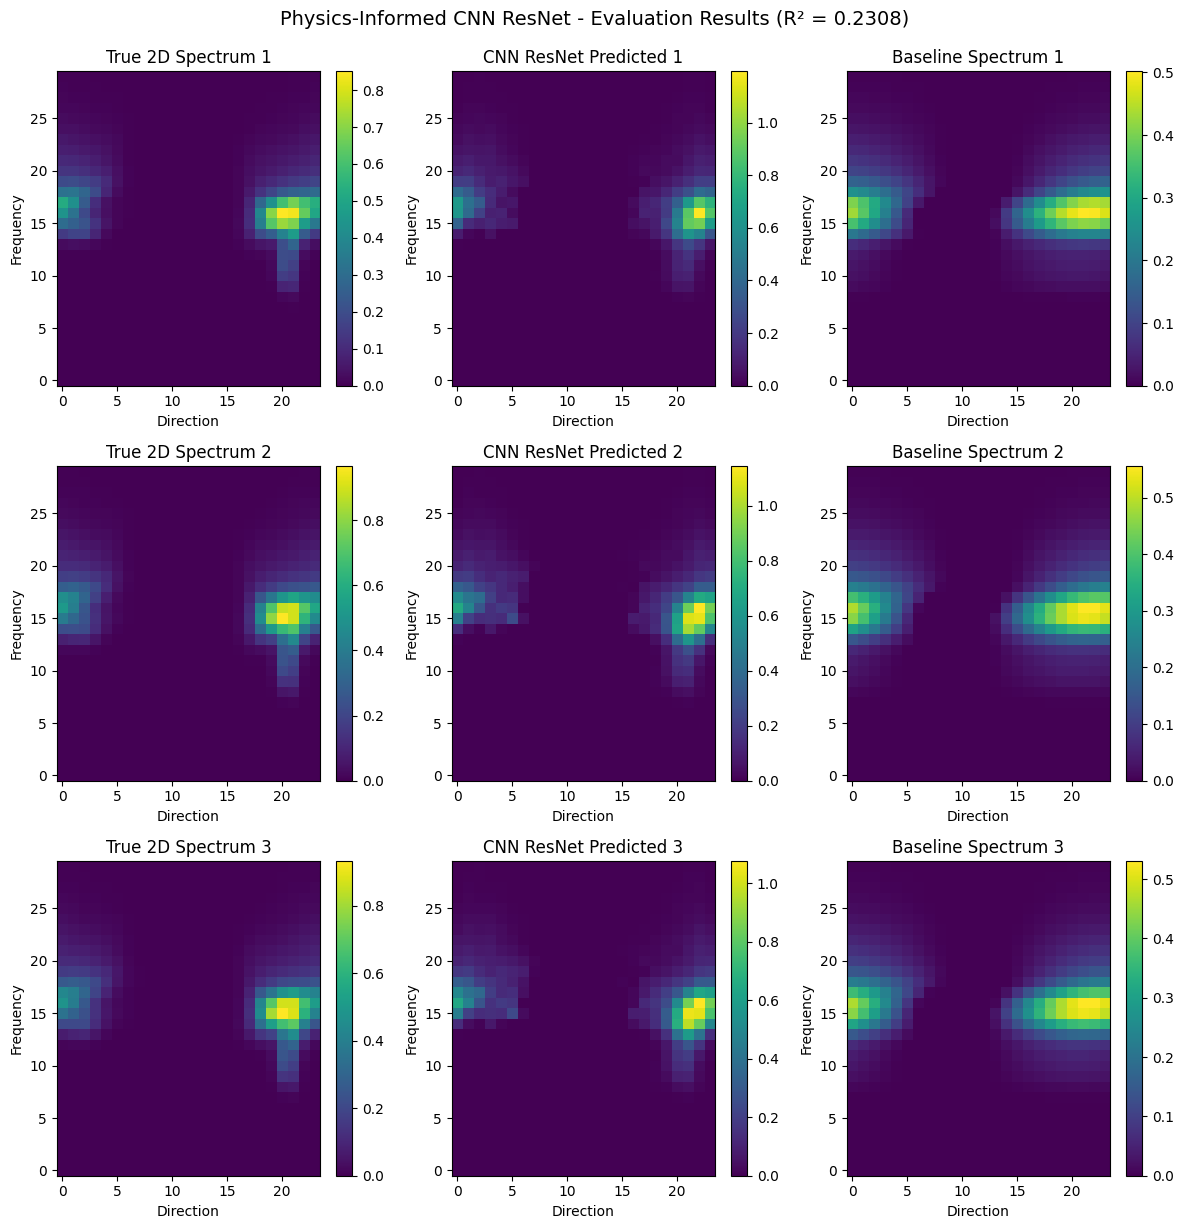

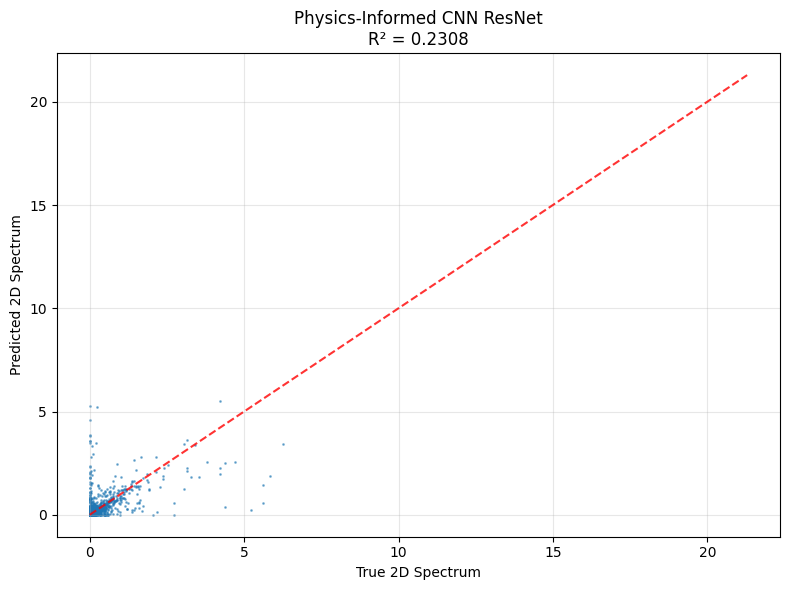


✅ Evaluation visualization complete!
Physics-Informed CNN ResNet performance:
  - R² = 0.230849
  - RMSE = 2.860456e-01
  - Physics Loss = 6.557877e-02


In [8]:
# Visualize Physics-Informed CNN ResNet evaluation results  
print("Creating visualization of evaluation results...")

# Use evaluation data from previous cells
num_examples = min(3, eval_target_np.shape[0])

fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4*num_examples))
if num_examples == 1:
    axes = axes.reshape(1, -1)

for i in range(num_examples):
    # True 2D spectrum
    im1 = axes[i, 0].imshow(eval_target_np[i], aspect='auto', cmap='viridis', 
                            origin='lower', interpolation='nearest')
    axes[i, 0].set_title(f'True 2D Spectrum {i+1}')
    axes[i, 0].set_xlabel('Direction')
    axes[i, 0].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[i, 0])
    
    # Predicted 2D spectrum  
    im2 = axes[i, 1].imshow(eval_pred_np[i], aspect='auto', cmap='viridis',
                            origin='lower', interpolation='nearest')
    axes[i, 1].set_title(f'CNN ResNet Predicted {i+1}')
    axes[i, 1].set_xlabel('Direction')
    axes[i, 1].set_ylabel('Frequency')
    plt.colorbar(im2, ax=axes[i, 1])
    
    # Baseline spectrum
    im3 = axes[i, 2].imshow(eval_baseline_np[i], aspect='auto', cmap='viridis',
                            origin='lower', interpolation='nearest')
    axes[i, 2].set_title(f'Baseline Spectrum {i+1}')
    axes[i, 2].set_xlabel('Direction')
    axes[i, 2].set_ylabel('Frequency')
    plt.colorbar(im3, ax=axes[i, 2])

plt.tight_layout()
plt.suptitle(f'Physics-Informed CNN ResNet - Evaluation Results (R² = {eval_r2:.4f})', 
             fontsize=14, y=1.02)
plt.show()

# Create scatter plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Sample points for better visualization
n_points = 10000
indices = np.random.choice(len(eval_y_flat), min(n_points, len(eval_y_flat)), replace=False)

ax.scatter(eval_y_flat[indices], eval_pred_flat[indices], alpha=0.5, s=1)
min_val = min(eval_y_flat.min(), eval_pred_flat.min())
max_val = max(eval_y_flat.max(), eval_pred_flat.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
ax.set_xlabel('True 2D Spectrum')
ax.set_ylabel('Predicted 2D Spectrum')
ax.set_title(f'Physics-Informed CNN ResNet\nR² = {eval_r2:.4f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Evaluation visualization complete!")
print(f"Physics-Informed CNN ResNet performance:")
print(f"  - R² = {eval_r2:.6f}")
print(f"  - RMSE = {np.sqrt(eval_mse):.6e}")
print(f"  - Physics Loss = {eval_total_loss.item():.6e}")